# Module 9 — Segmentation: The Methodology Landscape

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

- "Who are our users?" has three standard answers: slice them by a field that is already logged (rule-based slicing), score them on their buying behaviour (RFM), or let an algorithm group them by behaviour (clustering).
- Each method has a failure mode. Slicing only finds differences someone thought to slice by. RFM's scores depend on cut points someone chose, and quintiles split buyers into five groups even where most of them have the same value. Clustering always returns the number of groups it is asked for, even when the data has none.
- This module runs all three on the store's buyers, tests clustering on simulated data first (where the right answer is known), and turns the clusters into personas.

**What this module produces:**
1. Two rule-based slices of the store's buyers (by first-order month, and by category), next to the Product Analytics Case Study's slice.
2. RFM scores for every buyer, and a grid of where buyers and revenue sit.
3. A k-means clustering, checked on simulated data, with a choice of the number of groups and a check across random starts.
4. Personas: the clusters described in words and given names (any of the three methods can feed personas; clusters need it most, as they come unnamed), and what a different random start changes.

## From the curriculum

> ## <u>Module 9 — Segmentation: The Methodology Landscape</u>
>
> **Concepts**
> - Rule-based slicing by existing fields (what the Case Study did), and its
>   limit: it only finds the differences someone thought to slice by
> - RFM (Recency, Frequency, Monetary): scoring buyers on three behavioural axes
> - Behavioural clustering: k-means on scaled features, choosing k, checking
>   stability across random seeds, and validating on planted (simulated) groups
>   first
> - From clusters to personas: describing, naming, sizing, and the limit
>   (clusters describe, they don't explain)
>
> **Why it matters**
> "Who are our users?" is answered either by fields someone already logged or
> by behaviour. The second can find groups nobody named, but it can also find
> groups that aren't there. Knowing the methods and their failure modes is the
> skill.
>
> **Worked example**
> Rule-based slice recapped from the Product Analytics Case Study
> ([`04_Feature_Adoption_and_Segmentation.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/04_Feature_Adoption_and_Segmentation.ipynb),
> "Segmentation — does feature mix or outcome vary by student background?"),
> then RFM scores and k-means on the running dataset's buyers, with a seed
> stability check.
>
> **Resources**
> - [RFM and CLV: Using Iso-Value Curves for Customer Base Analysis](https://brucehardie.com/abstracts/abstract-fhl_rfm_clv_2005-02.html)
>   (Fader, Hardie & Lee, *Journal of Marketing Research* 42(4), 2005; abstract
>   page, verified).
> - [scikit-learn User Guide: Clustering](https://scikit-learn.org/stable/modules/clustering.html)
>   (verified): sections "2.3.2. K-means", "2.3.11.1. Rand index" (including the
>   adjusted Rand index) and "2.3.11.5. Silhouette Coefficient".
>
> **Exercise type:** fully worked: turn a cluster table into named personas, and
> say which ones a seed change breaks.
>
> **Interview angle:** "How would you segment our users?"

## Lesson

### Three ways to segment

- **Rule-based slicing:** split users by a field that is already logged (country, device, plan, signup month) and compare a metric across the slices. Simple and easy to explain; it only finds differences along the fields someone chose.
- **RFM:** score each buyer on three behavioural numbers (below), each turned into a score from 1 to 5. Still rules, but on behaviour instead of logged fields.
- **Clustering:** give an algorithm a few numbers per user and let it form the groups. It can find groups nobody named; it can also cut smooth data into groups that aren't really there.

### RFM

For each buyer, over October 2019 to February 2020:
- **[R] (Recency)** = days from the buyer's last order to 29 February 2020, the last day of the data. Smaller = more recent.
- **[F] (Frequency)** = the buyer's number of orders.
- **[M] (Monetary)** = the buyer's total revenue.

Each is turned into a **score from 1 to 5** (5 = best: most recent, most orders, most revenue), usually by splitting buyers into five equal-sized groups (**quintiles**).

### k-means clustering, step by step

k-means is one algorithm for clustering, the most common one; others exist (e.g. hierarchical clustering, DBSCAN).

1. Each buyer is a point described by a few numbers, the **features**. Features can be any numbers per buyer (views, cart adds, active days…); this module chooses the same three numbers RFM uses ([R], [F] and [M]: the raw days, orders and revenue, not the 1–5 scores), so the two methods can be compared: RFM groups buyers by cut points someone chose, k-means forms the groups itself.
2. Choose **k**, the number of groups.
3. Place k starting **centres** at random (scikit-learn's default spreads them apart, but they are still random; the random choice is fixed by a **seed** number, so a run can be repeated).
4. Assign every buyer to the nearest centre. **Distance** = straight-line distance: square the gap on each feature, add the squares up, take the square root.
5. Move each centre to the average of the buyers assigned to it.
6. Repeat steps 4 and 5 until no buyer changes group.

### From clusters to personas

A **persona** = a cluster described in words from its numbers (size, share of revenue, typical [R], [F] and [M]) and given a short name. A name describes the group; it doesn't explain why its buyers behave that way.

### Part 0 — What the data can and can't measure

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from common import connect, query, show, BLUE, ORANGE, AQUA, GREY

con = connect()
orders = query(con, "SELECT user_id, event_date, revenue FROM orders")
orders["event_date"] = pd.to_datetime(orders["event_date"])
last_day = pd.Timestamp("2020-02-29")
buyers = orders.groupby("user_id").agg(first_order=("event_date", "min"), last_order=("event_date", "max"),
                                       F=("revenue", "size"), M=("revenue", "sum"))
buyers["R"] = (last_day - buyers["last_order"]).dt.days
n_users = query(con, "SELECT COUNT(DISTINCT user_id) AS n FROM events_clean")["n"].iloc[0]
cat = query(con, "SELECT AVG(category_code IS NULL) AS name_missing, AVG(category_id IS NOT NULL) AS id_filled FROM events_clean").iloc[0]
print(f"users: {n_users:,}   buyers: {len(buyers):,} ({len(buyers) / n_users:.2%} of users)")
print(f"buyers with exactly 1 order: {(buyers['F'] == 1).sum():,} ({(buyers['F'] == 1).mean():.2%})")
print(f"category name (category_code) missing on {cat['name_missing']:.2%} of clean events;  category_id filled on {cat['id_filled']:.2%}")
print(f"[M] (revenue per buyer): median {buyers['M'].median():.2f}, largest {buyers['M'].max():,.2f}, "
      f"largest / median = {buyers['M'].max() / buyers['M'].median():.0f};  on the log scale: {np.log(buyers['M'].max()):.2f} - {np.log(buyers['M'].median()):.2f} = {np.log(buyers['M'].max()) - np.log(buyers['M'].median()):.1f}")

users: 164,270   buyers: 10,899 (6.63% of users)
buyers with exactly 1 order: 8,495 (77.94%)
category name (category_code) missing on 98.28% of clean events;  category_id filled on 100.00%
[M] (revenue per buyer): median 33.47, largest 2,715.87, largest / median = 81;  on the log scale: 7.91 - 3.51 = 4.4


- **No user attributes are logged:** the store's events carry no country, device, channel, age or plan, and the product category's name (`category_code`) is missing on 98.28% of clean events (Module 1). Its ID (`category_id`, a number with no name) is always filled. So rule-based slicing here can use time and the unnamed category (Part 1).
- **Buyers only:** [R], [F] and [M] are measured on purchases, so a user who never bought has none of them. RFM and clustering therefore cover only the users with at least one purchase: 10,899 of the 164,270 users in the 10% sample (6.63%; sample and cleaning rules: Module 1).
- **Most buyers bought once:** 77.94% have exactly one order. This shapes everything below: [F] can't be split into quintiles (Part 2), and [F] carries little more than one yes/no fact: one order, or more than one.
- **A five-month window:** [R] can't exceed 151 days (1 October to 29 February), and a buyer whose earlier orders fall before October has [F] and [M] undercounted and a first order dated later than it really was (Module 2).
- **[M] is gross revenue** (Module 1) and very uneven: median 33.47, largest 2,715.87. Before clustering, [F] and [M] are put on a natural-log scale (log 1 = 0, log 2 = 0.69). The log squeezes big values together: 2,715.87 is 81 times the median, but on the log scale it is only 4.4 above it. So a few big buyers don't each become a group of their own. [R] needs no log: it is spread evenly from 0 to 151 days.

### Part 1 — Rule-based slicing

#### What the Case Study showed

[`04_Feature_Adoption_and_Segmentation.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/04_Feature_Adoption_and_Segmentation.ipynb), section "Segmentation — does feature mix or outcome vary by student background?". An online-learning platform; students were sliced by `imd_band`, a logged field ranking the deprivation of the area they live in, in ten bands. Numbers quoted from its printed outputs (feature shares were printed as fractions; shown as percentages here):

| | most deprived band | least deprived band |
|---|---|---|
| success rate (passed the course) | 35.2% | 57.5% |
| activation rate (Module 4) | 54.8% | 67.3% |

Feature mix in the first 14 days was flat across all ten bands. Homepage share (the band's average share of a student's clicks that went to the homepage, Module 7) ran from 25.6% to 26.9%; quiz share from 6.9% to 9.0%.

The slice found one difference (outcome) and ruled out another (how the platform is used). It could only do so because `imd_band` was logged and someone chose to slice by it.

#### Scenario 1 — the store's buyers by first-order month

Each buyer is sliced by the month of their first order.

**Definitions:**
- **Day 0** = the day of the buyer's first order.
- **Repeat within 30 days** = within a 30-day window counting day 0 (days 0 to 29), another order on days 1 to 29 (a second order on day 0 doesn't count). 30 days is a chosen round number, as in Module 8.
- February first orders are left out: a buyer who first orders on 1 February would need data up to 1 March.

In [2]:
o = orders.merge(buyers["first_order"], left_on="user_id", right_index=True)
o["day"] = (o["event_date"] - o["first_order"]).dt.days
buyers["repeat_30"] = buyers.index.isin(o.loc[o["day"].between(1, 29), "user_id"])
buyers["first_month"] = buyers["first_order"].dt.strftime("%Y-%m")
sl = buyers[buyers["first_month"] < "2020-02"].groupby("first_month").agg(buyers=("repeat_30", "size"), repeaters=("repeat_30", "sum"))
sl["repeat %"] = sl["repeaters"] / sl["buyers"] * 100
show(pd.DataFrame({"first-order month": sl.index, "buyers": sl["buyers"].map("{:,}".format).values,
                   "repeat within 30 days": sl["repeaters"].map("{:,}".format).values,
                   "repeat %": sl["repeat %"].map("{:.2f}".format).values}))

first-order month  buyers  repeat within 30 days  repeat %
2019-10             2,445                    407     16.65
2019-11             2,716                    366     13.48
2019-12             1,966                    169      8.60
2020-01             2,023                    201      9.94


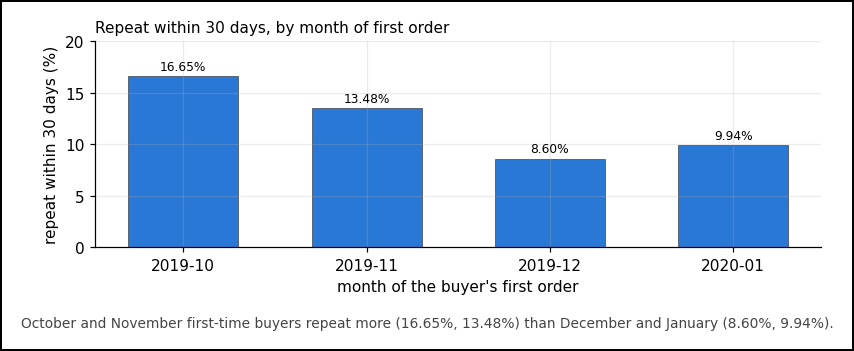

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 3.0))
ax.bar(sl.index, sl["repeat %"], color=BLUE, width=0.6, edgecolor="#333333", linewidth=0.4)
for x, v in zip(sl.index, sl["repeat %"]):
    ax.text(x, v + 0.3, f"{v:.2f}%", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 20)
ax.set_xlabel("month of the buyer's first order")
ax.set_ylabel("repeat within 30 days (%)")
ax.set_title("Repeat within 30 days, by month of first order", fontsize=10, loc="left")
fig.text(0.01, 0.020, f"October and November first-time buyers repeat more ({sl['repeat %'].iloc[0]:.2f}%, {sl['repeat %'].iloc[1]:.2f}%) than December and January ({sl['repeat %'].iloc[2]:.2f}%, {sl['repeat %'].iloc[3]:.2f}%).", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

**Observation:** 16.65% of October first-time buyers and 13.48% of November ones order again within 30 days, against 8.60% for December and 9.94% for January.

**Hypothesis:** two possible reasons, not tested here. October "first orders" include returning customers whose earlier orders predate the data (Part 0), and returning customers may reorder more. And the 30 days after a November first order run into December's holiday shopping.

**What slicing misses:** it shows that first-order months differ, and nothing else. Any group that doesn't line up with a field someone chose to slice by stays invisible.

#### Scenario 2 — the store's categories

**Definitions:**
- **Labels:** `category_id` has no names, so categories are labelled cat_1, cat_2, … by number of buyers over the five months (cat_1 = the most buyers).
- **Metric, per category:** of the buyers who bought from the category, the share who bought from it again within 30 days. Day 0 = the buyer's first purchase in that category; a repeat = a purchase from it on days 1 to 29. First purchases after 31 January are left out (no full window), as in Scenario 1.
- **A buyer counts in every category they bought from,** so the categories' buyer counts add up to more than the number of buyers.
- **Only the 10 biggest categories are shown** (10 is a chosen cutoff): smaller categories have few buyers, so their rates swing by chance. The rate across all categories is printed for reference.

In [4]:
lines = query(con, "SELECT user_id, event_date, category_id FROM events_clean WHERE event_type = 'purchase'")
lines["event_date"] = pd.to_datetime(lines["event_date"])
cat_buyers = lines.groupby("category_id")["user_id"].nunique().sort_values(ascending=False, kind="stable")
cat_label = {c: f"cat_{i}" for i, c in enumerate(cat_buyers.index, start=1)}
top10 = cat_buyers.index[:10]
other = lines.loc[~lines["category_id"].isin(top10), "user_id"].nunique()
show(pd.DataFrame({"category": ["buyers"], **{cat_label[c]: [f"{v:,}"] for c, v in cat_buyers.reindex(top10).items()},
                   f"all other ({len(cat_buyers) - 10} categories)": [f"{other:,}"]}))
print(f"\nbuyers in total: {lines['user_id'].nunique():,} (a buyer counts in every column they bought from, so the columns add up to more)")

category  cat_1  cat_2  cat_3  cat_4  cat_5  cat_6  cat_7  cat_8  cat_9  cat_10  all other (428 categories)
buyers    2,339  1,931  1,670  1,592  1,340  1,328  1,219  1,165  1,109   1,034                      10,411

buyers in total: 10,899 (a buyer counts in every column they bought from, so the columns add up to more)


In [5]:
pairs = lines.groupby(["user_id", "category_id"])["event_date"].min().rename("day0").reset_index()
lc = lines.merge(pairs, on=["user_id", "category_id"])
again = lc.loc[(lc["event_date"] - lc["day0"]).dt.days.between(1, 29), ["user_id", "category_id"]].drop_duplicates()
pairs["repeat"] = pairs.set_index(["user_id", "category_id"]).index.isin(again.set_index(["user_id", "category_id"]).index)
eligible = pairs[pairs["day0"] <= "2020-01-31"]
cs = eligible[eligible["category_id"].isin(top10)].groupby("category_id").agg(buyers=("repeat", "size"), repeaters=("repeat", "sum")).reindex(top10)
cs["repeat %"] = cs["repeaters"] / cs["buyers"] * 100
all_rate = eligible["repeat"].mean() * 100
in10 = eligible["category_id"].isin(top10)
print(f"(buyer, category) pairs with a full window, and their repeat rate:")
for name, part in [("10 biggest categories", eligible[in10]), (f"other {len(cat_buyers) - 10} categories", eligible[~in10]), (f"all {len(cat_buyers)} categories", eligible)]:
    print(f"  {name + ':':<22} {int(part['repeat'].sum()):>5,} / {len(part):>6,} pairs = {part['repeat'].mean():.2%}")
print()
show(pd.DataFrame({"category": [cat_label[c] for c in cs.index], "buyers with a full window": cs["buyers"].map("{:,}".format).values,
                   "repeat within 30 days": cs["repeaters"].map("{:,}".format).values,
                   "repeat %": cs["repeat %"].map("{:.2f}".format).values}))

(buyer, category) pairs with a full window, and their repeat rate:
  10 biggest categories:   867 / 12,258 pairs = 7.07%
  other 428 categories:  1,510 / 39,928 pairs = 3.78%
  all 438 categories:    2,377 / 52,186 pairs = 4.55%

category  buyers with a full window  repeat within 30 days  repeat %
cat_1                         1,921                    166      8.64
cat_2                         1,609                    100      6.22
cat_3                         1,399                     94      6.72
cat_4                         1,311                    117      8.92
cat_5                         1,185                    105      8.86
cat_6                         1,070                     78      7.29
cat_7                         1,012                     63      6.23
cat_8                           964                     54      5.60
cat_9                           924                     34      3.68
cat_10                          863                     56      6.49


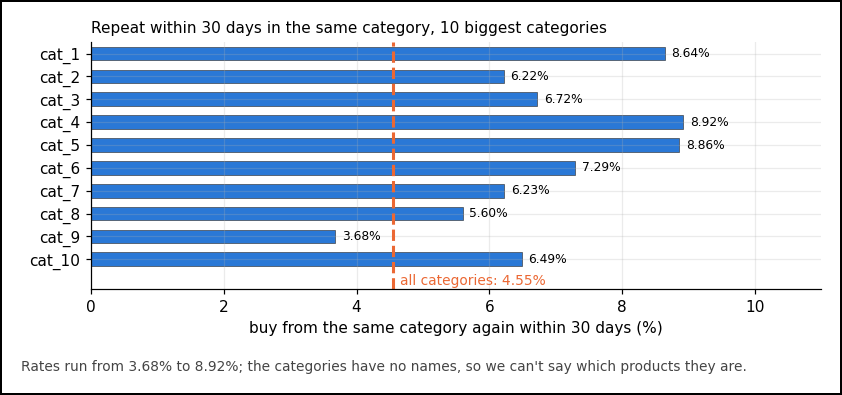

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
y = range(len(cs))[::-1]
ax.barh(list(y), cs["repeat %"], color=BLUE, height=0.6, edgecolor="#333333", linewidth=0.4)
for yy, v in zip(y, cs["repeat %"]):
    ax.text(v + 0.1, yy, f"{v:.2f}%", va="center", fontsize=8)
ax.axvline(all_rate, color=ORANGE, linewidth=2, linestyle="--")
ax.text(all_rate + 0.1, -0.95, f"all categories: {all_rate:.2f}%", fontsize=9, color=ORANGE, va="center")
ax.set_ylim(-1.3, len(cs) - 0.5)
ax.set_yticks(list(y), [cat_label[c] for c in cs.index])
ax.set_xlim(0, 11)
ax.set_xlabel("buy from the same category again within 30 days (%)")
ax.set_title("Repeat within 30 days in the same category, 10 biggest categories", fontsize=10, loc="left")
fig.text(0.01, 0.020, f"Rates run from {cs['repeat %'].min():.2f}% to {cs['repeat %'].max():.2f}%; the categories have no names, so we can't say which products they are.", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

**Observation:** among the 10 biggest categories, the share of buyers who buy from the same category again within 30 days runs from 3.68% (cat_9) to 8.92% (cat_4), with 863 to 1,921 buyers each. Nine of the ten are above the rate across all 438 categories (4.55%). Pooled, the 10 biggest repeat at 7.07% and the other 428 at 3.78%: smaller categories repeat less.

**Hypothesis:** categories differ in how soon customers use a product up and need more (an everyday item vs. a one-off purchase). Not testable here: the categories have no names.

**What this slice misses:** we can't say what cat_4 sells, so we can't explain or act on "cat_4 repeats most". The store, which knows what each `category_id` is, could. A slice is only as useful as the field's meaning to whoever reads it.

### Part 2 — RFM scores

**Scores:**
- **[R] and [M]:** quintiles, so each score holds about a fifth of the buyers (about, because buyers with the same [R] stay together; counts printed below). R's score is reversed (score 5 = the most recent fifth).
- **[F]:** quintiles don't work, because 77.94% of buyers have one order: the first three cuts land on 1 and the fourth on 2. Fixed bins instead, a chosen example: 1 order = score 1, 2 = 2, 3 = 3, 4–5 = 4, 6 or more = 5, picked so the top two bins still hold a few hundred buyers each (printed below).

In [7]:
buyers["R_score"] = pd.qcut(buyers["R"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
buyers["F_score"] = pd.cut(buyers["F"], [0, 1, 2, 3, 5, np.inf], labels=[1, 2, 3, 4, 5]).astype(int)
buyers["M_score"] = pd.qcut(buyers["M"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
r_cuts = pd.qcut(buyers["R"], 5).cat.categories
m_cuts = pd.qcut(buyers["M"], 5).cat.categories
total_rev = buyers["M"].sum()
r_rng = [f"{int(np.floor(c.left)) + 1}-{int(c.right)}" for c in r_cuts]
m_rng = [f"up to {c.right:,.2f}" for c in m_cuts[:4]] + [f"above {m_cuts[3].right:,.2f}"]
for col, order, rng, head in [("R_score", [5, 4, 3, 2, 1], r_rng, "days since last order"),
                              ("F_score", [1, 2, 3, 4, 5], ["1", "2", "3", "4-5", "6+"], "orders"),
                              ("M_score", [1, 2, 3, 4, 5], m_rng, "revenue")]:
    g = buyers.groupby(col).agg(buyers=("M", "size"), revenue=("M", "sum")).reindex(order)
    show(pd.DataFrame({f"[{col[0]}] score": g.index, head: rng,
                       "buyers": g["buyers"].map("{:,}".format).values,
                       "% of buyers": (g["buyers"] / len(buyers) * 100).map("{:.2f}".format).values,
                       "% of revenue": (g["revenue"] / total_rev * 100).map("{:.2f}".format).values}))
    print()
rs = buyers.groupby("R_score")["F"].apply(lambda s: (s == 1).mean() * 100)
print("share of buyers with 1 order, by [R] score: " + ",  ".join(f"{s}: {v:.2f}%" for s, v in rs.items()))

[R] score  days since last order  buyers  % of buyers  % of revenue
        5  0-24                    2,184        20.04         30.11
        4  25-51                   2,253        20.67         21.61
        3  52-85                   2,123        19.48         16.90
        2  86-113                  2,190        20.09         16.96
        1  114-151                 2,149        19.72         14.41

[F] score  orders  buyers  % of buyers  % of revenue
        1  1        8,495        77.94         49.50
        2  2        1,425        13.07         18.34
        3  3          480         4.40         10.43
        4  4-5        329         3.02         11.43
        5  6+         170         1.56         10.31

[M] score  revenue      buyers  % of buyers  % of revenue
        1  up to 14.21   2,180        20.00          3.41
        2  up to 25.07   2,182        20.02          6.62
        3  up to 41.97   2,178        19.98         11.66
        4  up to 72.75   2,179        19

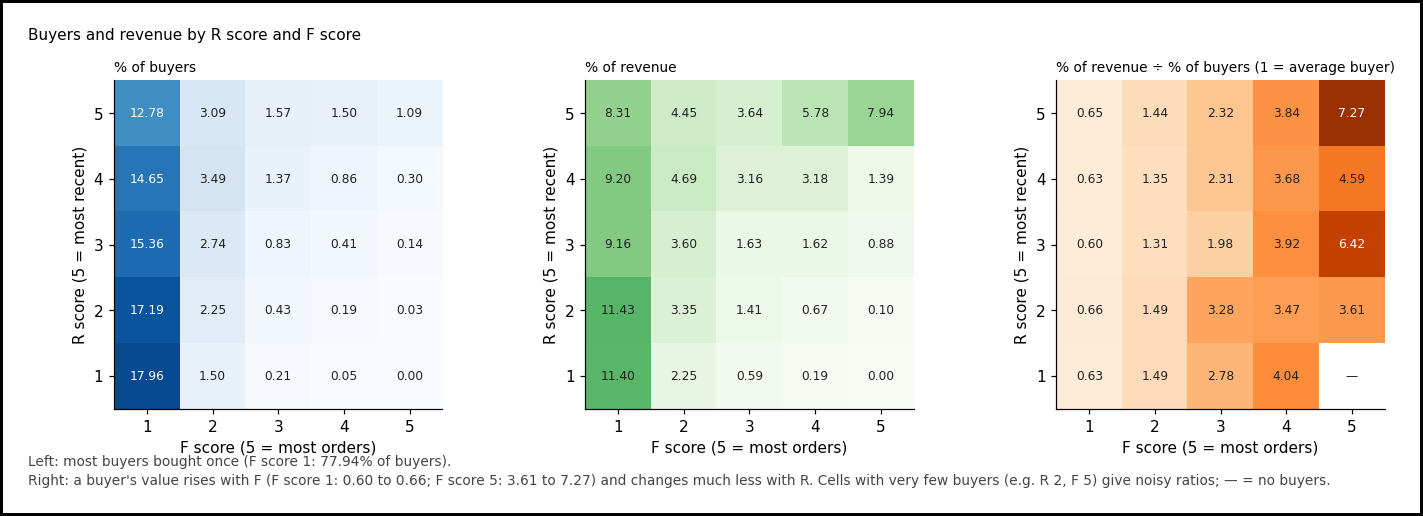

[R] score 5 and [F] score 5: 1.09% of buyers, 7.94% of revenue, ratio 7.94 / 1.09 = 7.27
[R] score 2 and [F] score 5: 3 buyers
ratio range per [F] score (across [R] scores): 1: 0.60 to 0.66,  2: 1.31 to 1.49,  3: 1.98 to 3.28,  4: 3.47 to 4.04,  5: 3.61 to 7.27


In [8]:
grid = buyers.groupby(["R_score", "F_score"]).agg(n=("M", "size"), rev=("M", "sum")).reindex(
    pd.MultiIndex.from_product([range(1, 6), range(1, 6)], names=["R_score", "F_score"]), fill_value=0)
share_b = (grid["n"] / len(buyers) * 100).unstack().sort_index(ascending=False)
share_r = (grid["rev"] / total_rev * 100).unstack().sort_index(ascending=False)
ratio = (share_r / share_b.where(share_b > 0))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, m, title, cmap, vmax, fmt in [(axes[0], share_b, "% of buyers", "Blues", 20, "{:.2f}"), (axes[1], share_r, "% of revenue", "Greens", 20, "{:.2f}"),
                                      (axes[2], ratio, "% of revenue ÷ % of buyers (1 = average buyer)", "Oranges", 8, "{:.2f}")]:
    ax.imshow(m.values, cmap=cmap, vmin=0, vmax=vmax)
    for i in range(5):
        for j in range(5):
            v = m.values[i, j]
            ax.text(j, i, "—" if np.isnan(v) else fmt.format(v), ha="center", va="center", fontsize=8,
                    color="white" if (not np.isnan(v) and v > vmax * 0.6) else "#222222")
    ax.set_xticks(range(5), m.columns); ax.set_yticks(range(5), m.index)
    ax.set_xlabel("F score (5 = most orders)"); ax.set_ylabel("R score (5 = most recent)")
    ax.set_title(title, fontsize=9, loc="left")
    ax.grid(False)
fig.suptitle("Buyers and revenue by R score and F score", fontsize=10, x=0.01, ha="left")
fig.text(0.01, 0.075, f"Left: most buyers bought once (F score 1: {share_b[1].sum():.2f}% of buyers).", fontsize=9, color="#444444")
fig.text(0.01, 0.035, f"Right: a buyer's value rises with F (F score 1: {ratio[1].min():.2f} to {ratio[1].max():.2f}; F score 5: {ratio[5].min():.2f} to {ratio[5].max():.2f}) "
                      "and changes much less with R. Cells with very few buyers (e.g. R 2, F 5) give noisy ratios; — = no buyers.", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.11, 1, 0.97]); plt.show()
print(f"[R] score 5 and [F] score 5: {grid.loc[(5, 5), 'n'] / len(buyers):.2%} of buyers, {grid.loc[(5, 5), 'rev'] / total_rev:.2%} of revenue, "
      f"ratio {grid.loc[(5, 5), 'rev'] / total_rev * 100:.2f} / {grid.loc[(5, 5), 'n'] / len(buyers) * 100:.2f} = {ratio.loc[5, 5]:.2f}")
print(f"[R] score 2 and [F] score 5: {int(grid.loc[(2, 5), 'n'])} buyers")
print("ratio range per [F] score (across [R] scores): " + ",  ".join(f"{f}: {ratio[f].min():.2f} to {ratio[f].max():.2f}" for f in range(1, 6)))

**Observation:** buyers with one order ([F] score 1) are 77.94% of buyers but bring 49.50% of revenue. Buyers with 6 or more orders ([F] score 5) are 1.56% of buyers and bring 10.31%. The most recent, most frequent cell ([R] 5, [F] 5) holds 1.09% of buyers and 7.94% of revenue.

**Observation:** [R] and [F] are linked. The share of one-order buyers falls from 91.07% in the least recent fifth ([R] score 1) to 63.78% in the most recent ([R] score 5). Part of this is mechanical: a buyer with more orders has more chances that one of them was recent.

**Observation:** what a buyer is worth (% of revenue ÷ % of buyers, right panel) follows [F] far more than [R]. One-order buyers are worth 0.60 to 0.66 of an average buyer at every [R] score; buyers with 6 or more orders, 3.61 to 7.27.

**What RFM misses:** the cut points are rules someone chose (quintiles, and the [F] bins above), and adding [M] as a third axis to the grid gives 5 × 5 × 5 = 125 cells, too many to act on one by one.

### Part 3 — What k-means does with and without groups (simulated)

**Why this Part:** a demonstration, not a test. It doesn't check k-means or change any result on the real buyers. On real data we never know whether groups exist, so we can't see k-means "hallucinate" groups there. On made-up data, where we know the answer, both cases can be shown:
- with **three planted groups**, k-means finds them;
- with **no groups**, k-means invents groups anyway (its main failure mode), and the two checks below look clearly different from the planted case.

**Why scaling:** the distance adds up squared gaps, so a feature measured in large numbers dominates. [R] runs from 0 to 151 days, while [F] is mostly 1 or 2: a gap of 50 days would swamp a gap of 1 order. Each feature is **standardized**: (value − its mean) ÷ its standard deviation, so every feature has mean 0 and standard deviation 1.

**Random starts:** different random starts can end in different groups, so scikit-learn can run several starts (`n_init`) and keep the one with the tightest groups (lowest inertia, Part 4).

The two simulated datasets:
- **Three planted groups,** 1,000 simulated buyers each, with [R], [F] and [M] drawn to look like recent one-time buyers, lapsed one-time buyers and recent repeat buyers. All numbers are a chosen example, picked to look like plausible store buyers (recent or lapsed, one order or several): [R] 0–60 or 90–150 days; [F] = 1, or 2 plus a random count averaging 1.5; [M] centred on 25 or 100, with a spread of 0.6 on the log scale. Note that no simulated buyer has [R] between 60–90 days: an empty band that makes recent and lapsed buyers easy to tell apart. Real buyers may not have one (checked later, in Part 5), so passing this test doesn't guarantee real groups.
- **No groups:** 3,000 points drawn from one bell-shaped cloud in three dimensions ([R], [F] and [M]). Any groups k-means returns here are cuts: sub-clouds of the one cloud.

#### Two checks on a clustering

Both are computed after k-means has finished, to make two decisions: whether the groups are worth trusting at all (this Part), and which k to use (Part 4).

- **Silhouette** (per buyer): a = the buyer's average distance to the other buyers in its own group; b = for each other group, the buyer's average distance to all of that group's buyers (distance as in step 4), keeping the smallest of these averages (that group is the "nearest other group"); silhouette = (b − a) ÷ the larger of a and b. It runs from −1 to 1: near 1, the buyer is much closer to its own group than to the next; near 0, it sits on a border; below 0 (down to −1), it is closer to another group than to its own, so it probably sits in the wrong group. Example numbers, chosen to show the arithmetic: a = 1, b = 3 gives (3 − 1) ÷ 3 = 0.67. The module reports the average over all buyers.
- **ARI (Adjusted Rand Index):** compares two groupings (e.g. two k-means runs). For every pair of buyers, it checks whether the two are together or apart in each grouping; the pair agrees if the answer is the same in both. ARI is how often pairs agree, scaled so that 1 = identical groupings and about 0 = no better than random. Used here two ways: a clustering vs. the true groups (simulated data only), and one random start vs. another (**stability**).

Both are run with k = 3. The planted data is turned into [R], log [F] and log [M] and standardized, as for the real buyers; the cloud is already on that scale (mean 0, standard deviation 1). Stability = the lowest ARI between any two of 10 single random starts (seeds 0 to 9, `n_init=1`; 10 is a chosen number), so 10 × 9 ÷ 2 = 45 pairs.

The table below has one row per dataset, in the same order as above. Each row is k-means with k = 3 on that dataset, and the checks on its result.

In [9]:
rng = np.random.default_rng(9)
n = 1000
sim_R = np.r_[rng.uniform(0, 60, n), rng.uniform(90, 150, n), rng.uniform(0, 60, n)]
sim_F = np.r_[np.ones(n), np.ones(n), 2 + rng.poisson(1.5, n)]
sim_M = np.r_[rng.lognormal(np.log(25), 0.6, n), rng.lognormal(np.log(25), 0.6, n), rng.lognormal(np.log(100), 0.6, n)]
truth = np.repeat([0, 1, 2], n)
X_planted = StandardScaler().fit_transform(np.c_[sim_R, np.log(sim_F), np.log(sim_M)])
X_blob = rng.normal(size=(3 * n, 3))

def stability(X, k, seeds=range(10)):
    runs = [KMeans(k, n_init=1, random_state=s).fit_predict(X) for s in seeds]
    return min(adjusted_rand_score(a, b) for a, b in itertools.combinations(runs, 2))

rows = []
for name, X in [("Three planted groups", X_planted), ("No groups", X_blob)]:
    labels = KMeans(3, n_init=10, random_state=0).fit_predict(X)
    rows.append({"simulated data": name, "silhouette": f"{silhouette_score(X, labels):.3f}",
                 "stability (lowest ARI, 45 pairs)": f"{stability(X, 3):.3f}",
                 "ARI vs. true groups": f"{adjusted_rand_score(truth, labels):.3f}" if X is X_planted else "n/a",
                 "group sizes": " / ".join(f"{c:,}" for c in sorted(np.bincount(labels), reverse=True))})
    if X is X_planted:
        planted_labels = labels
    else:
        blob_labels = labels
show(pd.DataFrame(rows))

simulated data        silhouette  stability (lowest ARI, 45 pairs)  ARI vs. true groups  group sizes
Three planted groups       0.544                             1.000                0.978  1,014 / 1,000 / 986
No groups                  0.218                             0.168                  n/a  1,037 / 1,026 / 937


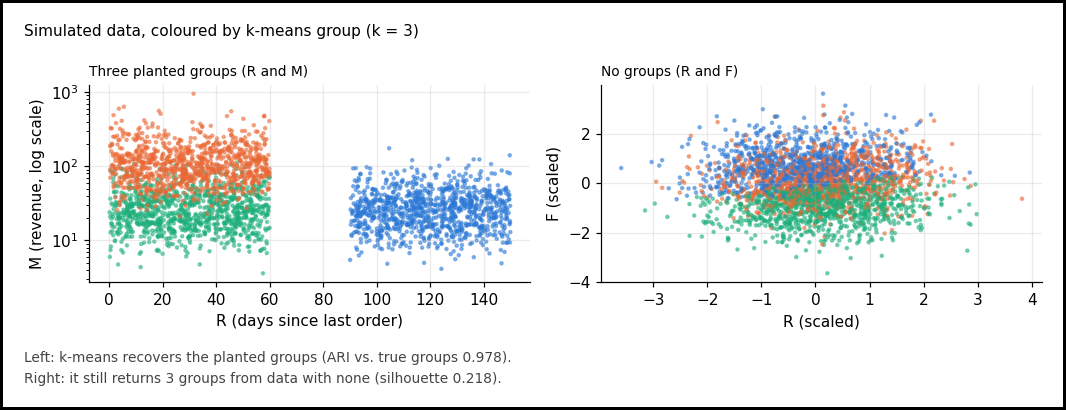

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
colors = np.array([BLUE, ORANGE, AQUA])
axes[0].scatter(sim_R, sim_M, c=colors[planted_labels], s=4, alpha=0.5)
axes[0].set_yscale("log"); axes[0].set_xlabel("R (days since last order)"); axes[0].set_ylabel("M (revenue, log scale)")
axes[0].set_title("Three planted groups (R and M)", fontsize=9, loc="left")
axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c=colors[blob_labels], s=4, alpha=0.5)
axes[1].set_xlabel("R (scaled)"); axes[1].set_ylabel("F (scaled)")
axes[1].set_title("No groups (R and F)", fontsize=9, loc="left")
fig.suptitle("Simulated data, coloured by k-means group (k = 3)", fontsize=10, x=0.01, ha="left")
fig.text(0.01, 0.075, f"Left: k-means recovers the planted groups (ARI vs. true groups {adjusted_rand_score(truth, planted_labels):.3f}).", fontsize=9, color="#444444")
fig.text(0.01, 0.020, f"Right: it still returns 3 groups from data with none (silhouette {silhouette_score(X_blob, blob_labels):.3f}).", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.12, 1, 1]); plt.show()

**Observation:** on the planted groups, k-means recovers the true groups almost exactly (ARI 0.978), the silhouette is 0.544, and every random start gives the same answer (lowest ARI 1.000).

**Observation:** on the cloud with no groups, k-means still returns three groups of similar size. The silhouette is lower (0.218), and different random starts give different groups (lowest ARI 0.168).

**Conclusion:** k-means always returns k groups, so "it found 3 groups" proves nothing. Two warning signs that the groups may be hallucinated: a low silhouette (No groups 0.218 vs. Three planted groups 0.544) and runs that disagree (stability 0.168 vs. 1.000). Passing both checks doesn't prove the groups are real (Part 5).

### Part 4 — k-means on the store's buyers

**Features:** [R], log([F]) and log([M]) for each of the 10,899 buyers, then standardized. Their means and standard deviations, used in the standardizing:

In [11]:
features = pd.DataFrame({"R": buyers["R"], "log F": np.log(buyers["F"]), "log M": np.log(buyers["M"])})
scaler = StandardScaler().fit(features)
X = scaler.transform(features)
show(pd.DataFrame({"feature": ["[R]", "log [F]", "log [M]"], "mean": [f"{v:.3f}" for v in scaler.mean_], "standard deviation": [f"{v:.3f}" for v in scaler.scale_]}))
ex = features.iloc[0]
print(f"\nexample, the first buyer: [R] = {ex['R']:.0f} days -> ({ex['R']:.0f} - {scaler.mean_[0]:.3f}) / {scaler.scale_[0]:.3f} = {X[0, 0]:.3f}")

feature    mean  standard deviation
[R]      69.705              43.672
log [F]   0.215               0.450
log [M]   3.507               1.001

example, the first buyer: [R] = 96 days -> (96 - 69.705) / 43.672 = 0.602


**Inertia** = the sum, over all buyers, of the squared distance from the buyer to its group's centre. Smaller means tighter groups.

**Choosing k:** for k = 2 to 8 (a chosen range), the best of 10 starts (`n_init=10`) gives inertia and silhouette; 10 single starts give stability, as in Part 3.

In [12]:
scan = []
for k in range(2, 9):
    km = KMeans(k, n_init=10, random_state=0).fit(X)
    singles = [KMeans(k, n_init=1, random_state=s).fit(X).inertia_ for s in range(10)]
    scan.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(X, km.labels_), "stability": stability(X, k),
                 "single_min": min(singles), "single_max": max(singles)})
scan = pd.DataFrame(scan)
show(pd.DataFrame({"k": scan["k"], "inertia": scan["inertia"].map("{:,.0f}".format),
                   "silhouette": scan["silhouette"].map("{:.3f}".format),
                   "stability (lowest ARI, 45 pairs)": scan["stability"].map("{:.3f}".format),
                   "single starts: highest inertia": scan["single_max"].map("{:,.0f}".format),
                   "difference % (highest vs. inertia)": ((scan["single_max"] / scan["inertia"] - 1) * 100).map("{:.2f}".format)}))

k  inertia  silhouette  stability (lowest ARI, 45 pairs)  single starts: highest inertia  difference % (highest vs. inertia)
2   20,162       0.442                             0.994                          20,162                                0.00
3   13,644       0.375                             0.983                          13,645                                0.01
4   11,139       0.349                             0.363                          11,688                                4.93
5    9,334       0.354                             0.463                           9,598                                2.83
6    7,750       0.341                             0.466                           8,366                                7.94
7    6,804       0.356                             0.493                           7,924                               16.46
8    6,135       0.349                             0.470                           6,724                                9.61


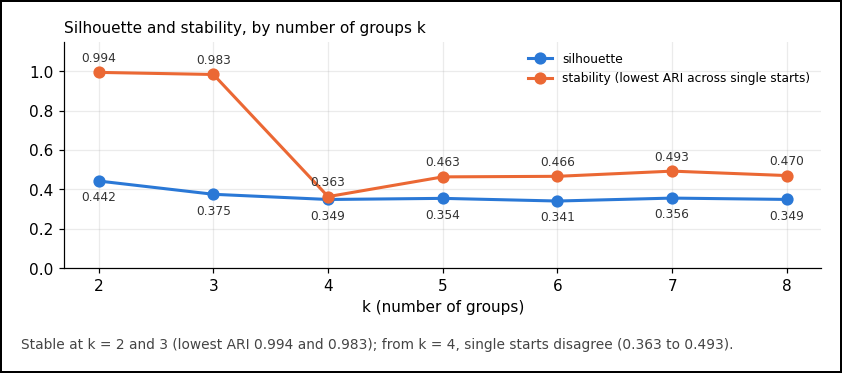

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(scan["k"], scan["silhouette"], marker="o", markersize=7, linewidth=2, color=BLUE, label="silhouette")
ax.plot(scan["k"], scan["stability"], marker="o", markersize=7, linewidth=2, color=ORANGE, label="stability (lowest ARI across single starts)")
for k, s, a in zip(scan["k"], scan["silhouette"], scan["stability"]):
    ax.text(k, s - 0.05, f"{s:.3f}", ha="center", va="top", fontsize=8, color="#333333")
    ax.text(k, a + 0.04, f"{a:.3f}", ha="center", va="bottom", fontsize=8, color="#333333")
ax.set_xticks(scan["k"]); ax.set_xlabel("k (number of groups)"); ax.set_ylim(0, 1.15)
ax.legend(frameon=False, loc="upper right", fontsize=8)
ax.set_title("Silhouette and stability, by number of groups k", fontsize=10, loc="left")
fig.text(0.01, 0.020, f"Stable at k = 2 and 3 (lowest ARI {scan['stability'].iloc[0]:.3f} and {scan['stability'].iloc[1]:.3f}); from k = 4, single starts disagree ({scan['stability'].iloc[2:].min():.3f} to {scan['stability'].iloc[2:].max():.3f}).", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

**Observation:** inertia falls as k grows (20,162 at k = 2, 6,135 at k = 8), as it always does, so it can't choose k by itself. The silhouette is highest at k = 2 (0.442), then 0.375 at k = 3 and between 0.341 and 0.356 after that, all above the no-groups cloud (0.218, Part 3) and below the planted groups (0.544): a rough reference only, since the simulated data differ in shape from the real buyers.

**Observation:** at k = 2 and 3 every single start ends in practically the same groups (lowest ARI 0.994 and 0.983). From k = 4, single starts disagree (lowest ARI 0.363 to 0.493): the data can be split into 4 or more groups in several different ways that are about equally tight (at k = 4, single-start inertia runs from 11,139 to 11,688, a 4.93% difference).

**The choice, k = 3:** stable (0.983), the last k before stability drops at k = 4, and the second-highest silhouette (0.375). k = 2 would also be a defensible choice.

### Part 5 — From clusters to personas

The k = 3 groups (best of 10 starts), labelled A, B, C after sorting by median [F] (highest first), ties broken by median [R] (lowest first). The sort is a chosen convention: it only sets the letters, not the groups. **ID** = the RFM scores (Part 2's cut points) of the group's median [R], [F] and [M]; a group spans many score combinations, so the ID describes its typical buyer only.

Below the table: the lowest and highest [R] among one-order buyers in groups B and C, to show where k-means drew the border between them. Typical values are medians.

In [14]:
def profile(labels):
    d = buyers.assign(group=labels).groupby("group").agg(
        buyers=("M", "size"), R=("R", "median"), F=("F", "median"), one=("F", lambda s: (s == 1).mean() * 100), M=("M", "median"), revenue=("M", "sum"))
    d = d.sort_values(["F", "R"], ascending=[False, True])
    d.index = [chr(65 + i) for i in range(len(d))]
    return d

def rfm_id(row):
    r = [5, 4, 3, 2, 1][r_cuts.get_loc(row["R"])]
    f = int(pd.cut([row["F"]], [0, 1, 2, 3, 5, np.inf], labels=[1, 2, 3, 4, 5])[0])
    m = [1, 2, 3, 4, 5][m_cuts.get_loc(row["M"])]
    return f"R{r}F{f}M{m}"

def show_profile(d, names=None):
    show(pd.DataFrame({"group": d.index, "ID": [rfm_id(d.loc[g]) for g in d.index], **({"persona": [names[g] for g in d.index]} if names else {}), "buyers": d["buyers"].map("{:,}".format).values,
                       "% of buyers": (d["buyers"] / len(buyers) * 100).map("{:.2f}".format).values,
                       "% of revenue": (d["revenue"] / total_rev * 100).map("{:.2f}".format).values,
                       "[R], median days": d["R"].map("{:.0f}".format).values,
                       "[F], median orders": d["F"].map("{:.0f}".format).values,
                       "% with 1 order": d["one"].map("{:.2f}".format).values,
                       "[M], median revenue": d["M"].map("{:.2f}".format).values}))

def relabel(labels):
    d = buyers.assign(group=labels).groupby("group").agg(F=("F", "median"), R=("R", "median")).sort_values(["F", "R"], ascending=[False, True])
    return pd.Series(labels, index=buyers.index).map({g: chr(65 + i) for i, g in enumerate(d.index)})

k3 = relabel(KMeans(3, n_init=10, random_state=0).fit_predict(X))
show_profile(profile(k3.values), names={"A": "Repeat buyers", "B": "Recent one-time buyers", "C": "Lapsed one-time buyers"})
one = buyers["F"] == 1
print()
for g in ["B", "C"]:
    r = buyers.loc[one & (k3 == g), "R"]
    print(f"one-order buyers in group {g}: [R] from {r.min()} to {r.max()} days")
print(f"buyers with 2+ orders outside group A: {(~one & (k3 != 'A')).sum():,} of {(~one).sum():,}")
overlap = one & buyers["R"].between(67, 84)
print("B and C overlap at [R] 67-84 days; inside the overlap, one-order buyers' median [M]: " + ",  ".join(f"group {g}: {buyers.loc[overlap & (k3 == g), 'M'].median():.2f} ({(overlap & (k3 == g)).sum():,} buyers)" for g in ["B", "C"]))
print()
print("for comparison, k = 2 (best of 10 starts):")
show_profile(profile(relabel(KMeans(2, n_init=10, random_state=0).fit_predict(X)).values), names={"A": "Repeat buyers", "B": "One-time buyers"})

group  ID      persona                 buyers  % of buyers  % of revenue  [R], median days  [F], median orders  % with 1 order  [M], median revenue
A      R4F3M5  Repeat buyers            1,949        17.88         48.92                34                   3            0.67               103.14
B      R4F1M2  Recent one-time buyers   4,125        37.85         21.96                34                   1           95.03                24.22
C      R2F1M3  Lapsed one-time buyers   4,825        44.27         29.12               108                   1           94.55                27.43

one-order buyers in group B: [R] from 0 to 84 days
one-order buyers in group C: [R] from 67 to 151 days
buyers with 2+ orders outside group A: 468 of 2,404
B and C overlap at [R] 67-84 days; inside the overlap, one-order buyers' median [M]: group B: 16.54 (366 buyers),  group C: 32.69 (682 buyers)

for comparison, k = 2 (best of 10 starts):
group  ID      persona          buyers  % of buyers  % of revenu

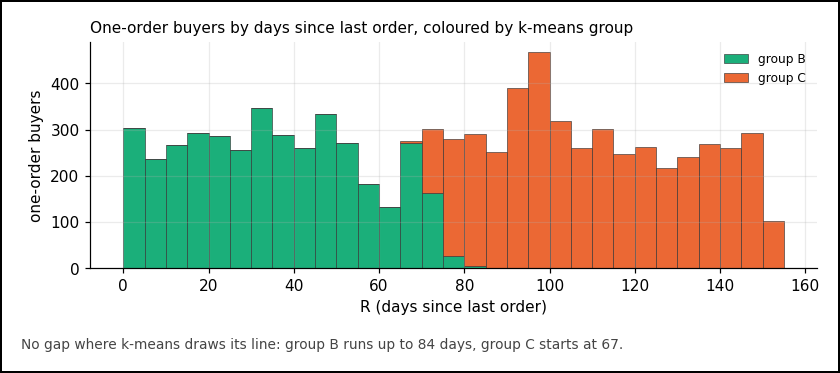

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
bins = np.arange(0, 156, 5)
ax.hist([buyers.loc[one & (k3 == g), "R"] for g in ["B", "C"]], bins=bins, stacked=True, color=[AQUA, ORANGE], label=["group B", "group C"], edgecolor="#333333", linewidth=0.4)
ax.set_xlabel("R (days since last order)"); ax.set_ylabel("one-order buyers")
ax.legend(frameon=False, fontsize=8)
ax.set_title("One-order buyers by days since last order, coloured by k-means group", fontsize=10, loc="left")
fig.text(0.01, 0.020, f"No gap where k-means draws its line: group B runs up to {buyers.loc[one & (k3 == 'B'), 'R'].max()} days, group C starts at {buyers.loc[one & (k3 == 'C'), 'R'].min()}.", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

**Personas, named from the table above:**
- **A, repeat buyers:** 17.88% of buyers, 48.92% of revenue; median 3 orders, last order a median 34 days before the data ends.
- **B, recent one-time buyers:** 37.85% of buyers, 21.96% of revenue; 95.03% have one order, a median 34 days ago.
- **C, lapsed one-time buyers:** 44.27% of buyers, 29.12% of revenue; 94.55% have one order, a median 108 days ago.

**Observation:** the split between A and the rest falls on a step in a whole-number feature: one order vs. two or more. The split between B and C has no natural break: buyers exist at every [R] around the border (67–84 days). Inside that range, the lower spenders go to B (median [M] 16.54 vs. 32.69 in C).

**Observation:** the groups are close to simple rules: "2+ orders" for A, and a recency cut for B vs. C. 468 of the 2,404 buyers with 2 or more orders still land in B or C, so the rule and the cluster are not identical.

**Conclusion:** here, k-means on [R], [F] and [M] found one boundary at a step in the data (one order vs. more) and one convenient cut (recent vs. lapsed). k = 2 (printed above) is the first boundary alone. Both are useful for describing buyers, e.g. group C (4,825 lapsed one-time buyers) is the audience for a campaign to bring them back, but neither explains why those buyers didn't come back.

## Exercises

Both exercises use two of Part 4's ten k = 4 runs, each from its own random start: **run 1** and **run 2**.

### Exercise 1 — Turn a cluster table into personas

**The question:** below is run 1's result. Name each group as a persona.

In [16]:
k4_seed0 = relabel(KMeans(4, n_init=1, random_state=0).fit_predict(X))
show_profile(profile(k4_seed0.values))

group  ID      buyers  % of buyers  % of revenue  [R], median days  [F], median orders  % with 1 order  [M], median revenue
A      R4F3M5   1,751        16.07         45.70                32                   3            0.34               109.07
B      R4F1M3   3,665        33.63         19.98                31                   1           93.64                26.18
C      R2F1M1   2,625        24.08          5.88               101                   1           98.40                13.65
D      R2F1M4   2,858        26.22         28.44               106                   1           86.56                47.50


**Step 1, the column that separates most:** median [M], different for all four groups: A 109.07, D 47.50, B 26.18, C 13.65.

**Step 2, then recency:** median [R] splits the groups 2/2: A and B bought recently (median 32 and 31 days ago), C and D about 100 days ago (101 and 106).

**Step 3, then orders:** median [F] is 3 for A and 1 for B, C and D. A is the only group of repeat buyers.

**The answer:**
- **A, repeat buyers:** 16.07% of buyers, 45.70% of revenue.
- **B, recent one-time buyers:** 33.63% of buyers.
- **C, lapsed one-time, small spenders:** 24.08% of buyers, 5.88% of revenue.
- **D, lapsed one-time, bigger spenders:** 26.22% of buyers, 28.44% of revenue.

### Exercise 2 — Which personas does a different random start break?

**The question:** run 2 ended in different groups. Which of run 1's personas survive in run 2, and which break?

**Step 1, the run-2 groups:**

In [17]:
k4_seed3 = relabel(KMeans(4, n_init=1, random_state=3).fit_predict(X))
show_profile(profile(k4_seed3.values))

group  ID      buyers  % of buyers  % of revenue  [R], median days  [F], median orders  % with 1 order  [M], median revenue
A      R5F4M5     700         6.42         29.40                20                   4            0.00               195.50
B      R4F2M4   1,667        15.29         24.04                48                   2            5.22                70.31
C      R4F1M2   3,897        35.76         19.69                34                   1           99.44                23.51
D      R2F1M3   4,635        42.53         26.87               109                   1           97.80                26.44


**Step 2, where each run-1 group goes** (first table: each row adds up to 100%), **and where each run-2 group came from** (second table: the same buyers, each column adds up to 100%):

In [18]:
ct = pd.crosstab(k4_seed0, k4_seed3, normalize="index") * 100
show(pd.DataFrame({"run-1 group": [f"{g} (run 1)" for g in ct.index],
                   **{f"to {g} (run 2) %": ct[g].map("{:.2f}".format).values for g in ct.columns}}))
print()
ctc = pd.crosstab(k4_seed0, k4_seed3, normalize="columns") * 100
show(pd.DataFrame({"came from": [f"{g} (run 1)" for g in ctc.index],
                   **{f"{g} (run 2) %": ctc[g].map("{:.2f}".format).values for g in ctc.columns}}))

run-1 group  to A (run 2) %  to B (run 2) %  to C (run 2) %  to D (run 2) %
A (run 1)             39.98           60.02            0.00            0.00
B (run 1)              0.00            6.58           93.07            0.35
C (run 1)              0.00            0.53           14.74           84.72
D (run 1)              0.00           12.63            3.46           83.90

came from  A (run 2) %  B (run 2) %  C (run 2) %  D (run 2) %
A (run 1)       100.00        63.05         0.00         0.00
B (run 1)         0.00        14.46        87.53         0.28
C (run 1)         0.00         0.84         9.93        47.98
D (run 1)         0.00        21.66         2.54        51.74


**Step 3, the answer:**
- **Survives:** recent one-time buyers (run 1's B = run 2's C). *Why:* 93.07% of run 1's B went to run 2's C, and 87.53% of run 2's C came from run 1's B, so they're largely the same people.
- **Survives, split in two:** repeat buyers (run 1's A → run 2's A and B). *Why:* all of run 1's A goes to run 2's A (39.98%) or B (60.02%), and both are repeat buyers (median 4 and 2 orders). The persona stays, but run 2 cuts it by how often they buy.
- **Breaks:** lapsed small vs. bigger spenders (run 1's C and D → run 2's D). *Why:* 84.72% of C and 83.90% of D land in run 2's D, which is made of the two almost equally (47.98% and 51.74%), so run 2 no longer tells them apart.

## Key takeaways

- **Recap:** rule-based slicing finds differences only along the fields someone logged and chose (Case Study: success 35.2% vs. 57.5% across deprivation bands). This store logs no user attributes; its slices are by first-order month and by an unnamed category ID.
- **Observation:** 77.94% of the store's buyers bought once; they bring 49.50% of revenue.
- **Observation:** k-means returned three groups even from simulated data with no groups (silhouette 0.218, unstable across starts); on planted groups it found them (ARI 0.978).
- **Observation:** on the store's buyers, k = 3 is stable: repeat buyers (17.88% of buyers, 48.92% of revenue), recent one-time and lapsed one-time buyers. The one-time split is a cut through recency where the data has no gap.
- **Conclusion:** report silhouette and stability across random starts with every clustering, and treat clusters as descriptions, not explanations.